<h1>Activity 3</h1>
<h3>Analyst: Karl Gabriel Dellova</h3>
<hr>

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway
from sklearn.linear_model import LinearRegression

In [2]:
dengue = pd.read_csv('DATASET/dengue.csv')
dengue

,Month,Year,Region,Dengue_Cases,Dengue_Deaths
0,January,2016,Region I,705,1
1,February,2016,Region I,374,0
2,March,2016,Region I,276,0
3,April,2016,Region I,240,2
4,May,2016,Region I,243,1
...,...,...,...,...,...
1015,August,2020,BARMM,91,0
1016,September,2020,BARMM,16,8
1017,October,2020,BARMM,13,9
1018,November,2020,BARMM,15,1


In [3]:
dengue['Year'] = dengue['Year'].astype('int')
region_order = ['BARMM', 'CAR', 'NCR', 'Region I', 'Region II', 'Region III', 'Region IV-A', 'Region IV-B', 'Region IX', 'Region V', 'Region VI', 'Region VII', 'Region VIII', 'Region X', 'Region XI', 'Region XII', 'Region XIII']
dengue['Region'] = pd.Categorical(dengue['Region'], categories = region_order, ordered = True)
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
dengue['Month'] = pd.Categorical(dengue['Month'], categories = month_order, ordered = True)

In [4]:
dengue.dtypes

Month            category
Year                int64
Region           category
Dengue_Cases        int64
Dengue_Deaths       int64
dtype: object

<h1>Q1: Whats the Yearly Dengue Cases in Region XIII</h1>
<hr>

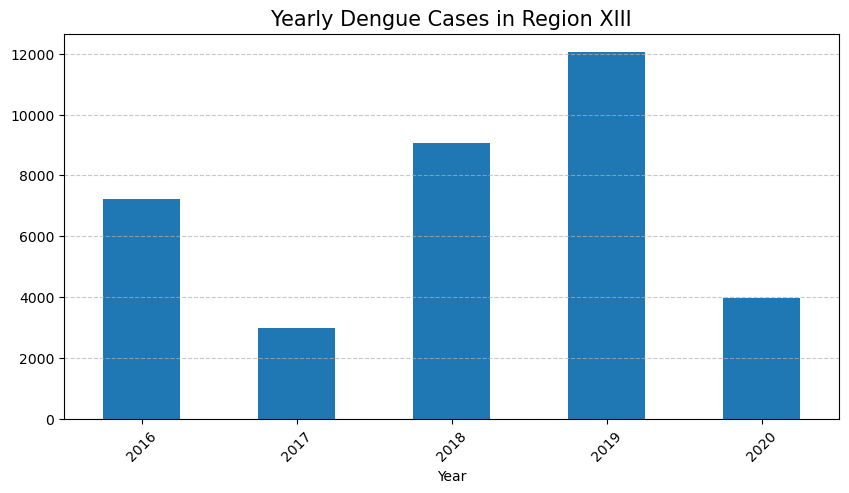

In [5]:
region_4a = dengue[dengue['Region'] == 'Region XIII']
yearly_cases = region_4a.groupby('Year')['Dengue_Cases'].sum()

plt.figure(figsize=(10,5))
yearly_cases.sort_index().plot(kind='bar')
plt.title('Yearly Dengue Cases in Region XIII', fontsize = 15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.xlable('Year')
# plt.ylable('Dengue Cases')
plt.xticks(rotation=45)
plt.show()

<h4>Insight 1: 2019 is the year with the most dengue cases with more than 12000 cases in region XIII</h4>

<h4>Insight 2: 2017 is the year with the lowest recorded cases of dengue as well as 2020 with the seconde highest</h4>

<h1>Q2: Whats the Monthly Cases of Dengue in Region IV-A During the year 2016</h1>
<hr>

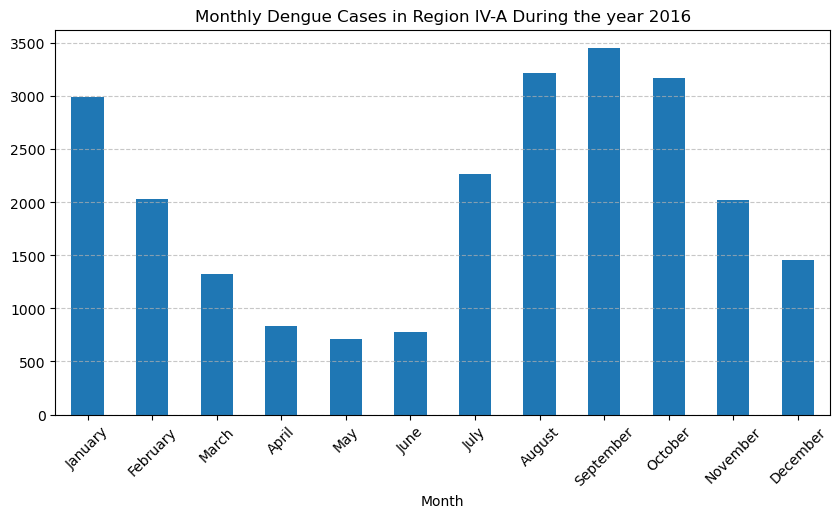

In [6]:
dengue4a_16 = dengue[(dengue['Year'] == 2016) & (dengue['Region'] == 'Region IV-A')]
monthly16_4a = dengue4a_16.groupby('Month')['Dengue_Cases'].sum()


plt.figure(figsize=(10,5))
monthly16_4a.sort_index().plot(kind='bar')
plt.title('Monthly Dengue Cases in Region IV-A During the year 2016')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.show()

<h4>Insight 3: August, September, and October are the three months with the highest recorded cases in 2016 with all three of them having more than 3000 cases</h4>

<h4>Insight 4: April, May, and June on the other hand are the months with the lowest recorded cases being less than 1000</h4>

<h1>Q3: Which Region has the most Dengue Deaths during 2019</h1>
<hr>

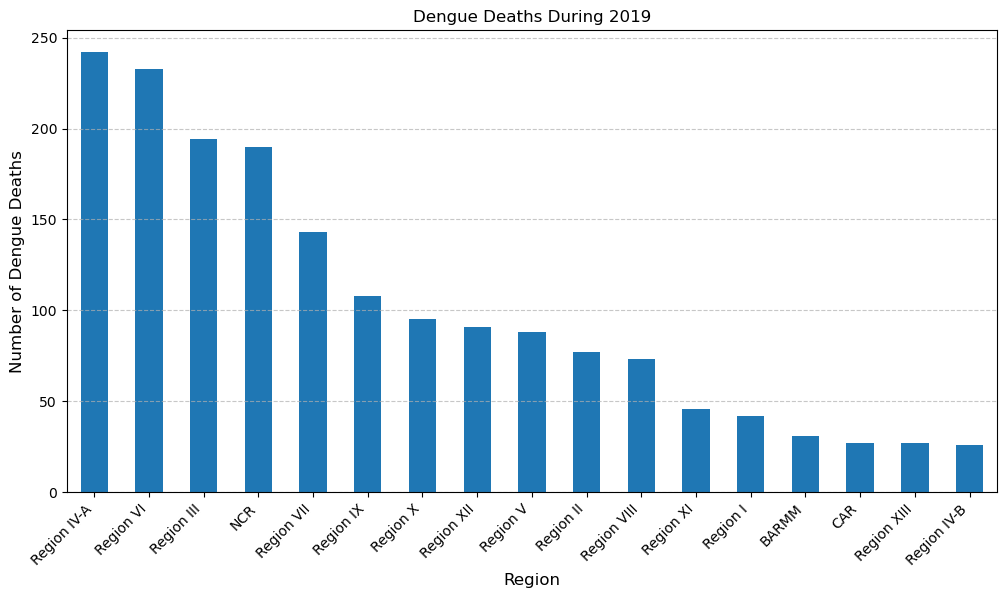

In [7]:
dengue19 = dengue[dengue['Year'] == 2019]
dengue19_deaths = dengue19.groupby('Region')['Dengue_Deaths'].sum().sort_values(ascending=False)


plt.figure(figsize=(12,6))
dengue19_deaths.plot(kind = 'bar')

plt.title('Dengue Deaths During 2019')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Number of Dengue Deaths', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

<h1>Q4: Which Month has the Most Dengue cases during 2017 in Region IV-B</h1>
<hr>

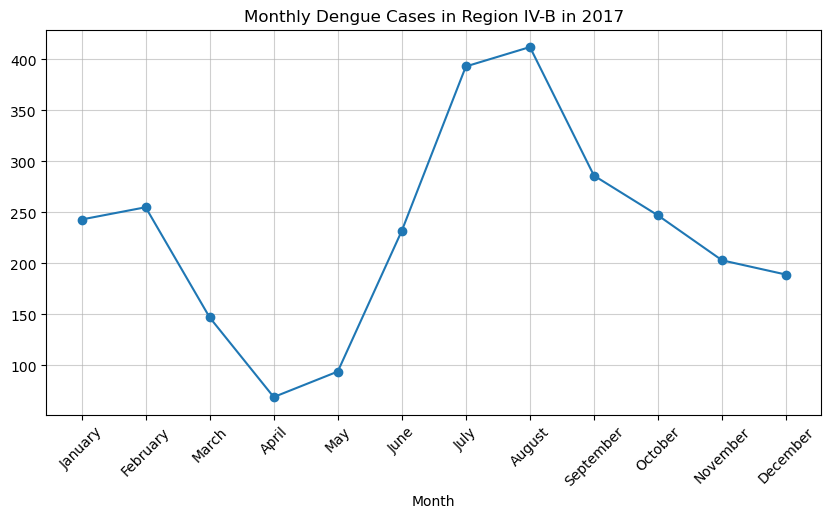

In [36]:
ivb_17 = dengue[(dengue['Year'] == 2017) & (dengue['Region'] == 'Region IV-B')]
monthly_IVB = ivb_17.groupby('Month')['Dengue_Cases'].max()

monthly_IVB.plot(
    marker = 'o',
    figsize = (10,5),
    title = 'Monthly Dengue Cases in Region IV-B in 2017'
)
plt.xticks(
    range(0, 12),
    ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'], 
    rotation=45
)
plt.grid(alpha = 0.6)
plt.show()

<h1>Q5: How much the number of Dengue Deaths have Increased/Decreased over the years (2016-2020)</h1>
<hr>

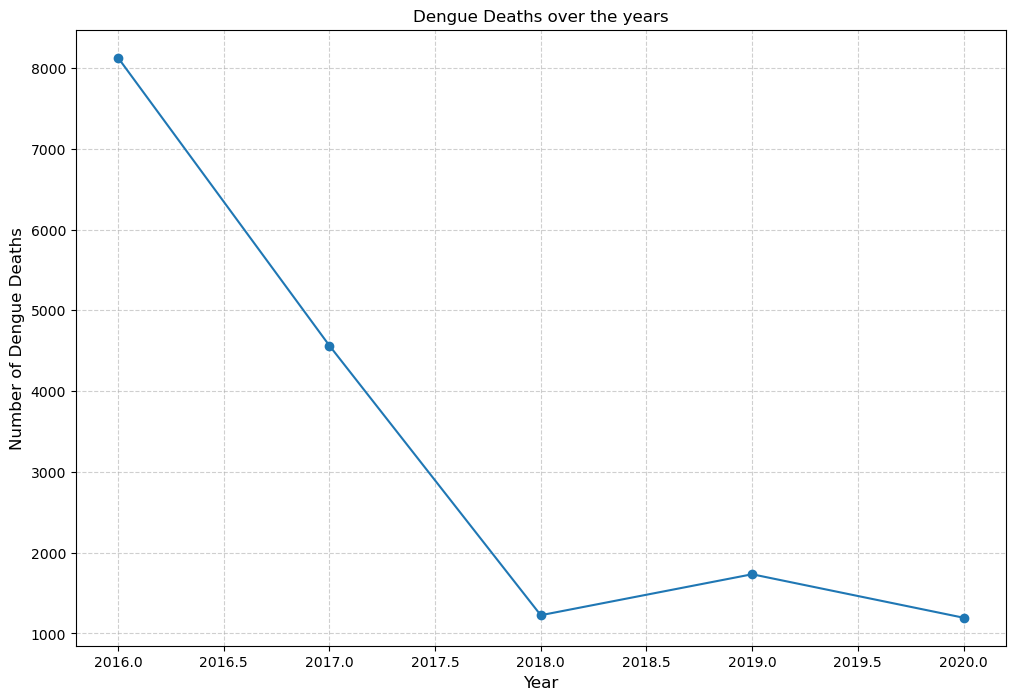

In [40]:
yearly_deaths = dengue.groupby('Year')['Dengue_Deaths'].sum()

plt.figure(figsize=(12,8))
plt.plot(
    yearly_deaths.index, 
    yearly_deaths.values,
    marker = 'o',
)
plt.title('Dengue Deaths over the years')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Dengue Deaths', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

<h4>Insight 9: From 2016 to 2018 the record of Dengue Deaths have drastically reduced to less than 2000</h4>

<h4>Insight 10: During 2018 there has been an increase in recorded Dengue Deaths peaking in the year 2019 where it continues to reduce in 2020</h4>